In [2]:
import math
import numpy as np
import PIL.Image as Image
import matplotlib.pyplot as plt

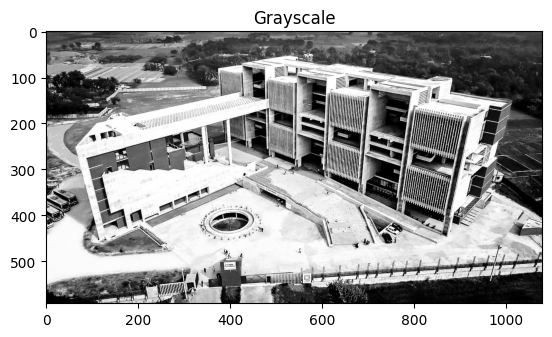

In [3]:
img = Image.open("images/vu.jpg").convert("L")
img = np.array(img)

H, W = img.shape

plt.title("Grayscale")
plt.imshow(img, cmap="gray")
plt.show()

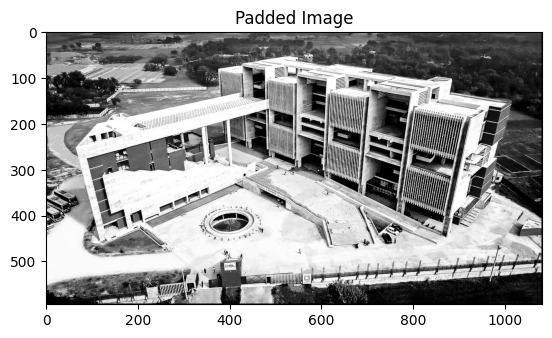

In [ ]:
sobel_vertical_kernel = np.array(
    [
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ]
)

sobel_horizontal_kernel = np.array(
    [
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ]
)


K_H, K_W = 3, 3

pad_width = K_H // 2

padded_img = np.zeros(
    shape=(
        H+2*pad_width,
        W+2*pad_width
    )
)

padded_img[
    pad_width:H+pad_width,
    pad_width:W+pad_width
] = img

plt.title("Padded Image")
plt.imshow(padded_img, cmap="gray")
plt.show()

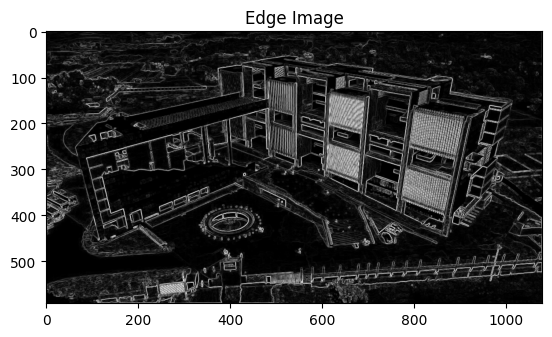

In [5]:
vertical_edge_img = np.zeros(shape=(H, W))
horizontal_edge_img = np.zeros(shape=(H, W))
sharp_img = np.zeros(shape=(H, W))

for y in range(H):
    for x in range(W):
        window = padded_img[y:y+K_H, x:x+K_W]

        v = np.sum(window * sobel_vertical_kernel)
        h = np.sum(window * sobel_horizontal_kernel)

        vertical_edge_img[y, x] = v
        horizontal_edge_img[y, x] = h

merged_edge_img = (
    vertical_edge_img ** 2 +
    horizontal_edge_img ** 2
) ** 0.5

plt.title("Edge Image")
plt.imshow(merged_edge_img, cmap="gray")
plt.show()

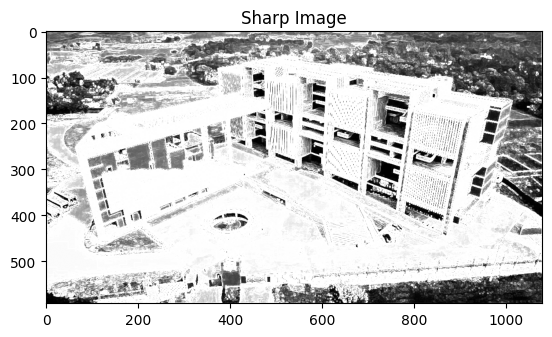

In [8]:
k = 0.2
sharp_img = img + 1 * merged_edge_img
sharp_img = np.clip(sharp_img, 0, 255)

plt.title("Sharp Image")
plt.imshow(sharp_img, cmap="gray")
plt.show()